# Preamble

In [98]:
from matplotlib import pyplot as plt # plotting
import math
import sklearn
#import GPy
#np.random.seed(101)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process import kernels
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ExpSineSquared, ConstantKernel, DotProduct


import scipy
from tqdm import tqdm
#import pytorch as torch
import numpy as np
import gymnasium as gym
import gym_unbalanced_disk, time

# Function definitions

In [99]:
def rbf(x1,x2,width):
    return np.exp(-0.5* (x1-x2)**2/width)

def demonstrate(full_range,y1,f,var,indices,name):
    plt.figure(figsize=(16,4.8))
    plt.title(name)
    plt.plot(full_range,y1,label="Data",marker=".")
    plt.plot(full_range[indices],f,label="Prediction")
    plt.fill_between(full_range[indices],f+var,f-var,alpha=0.3,label='est std out')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()
    return

def quick_plot(full_range,f,var,name):
    plt.figure(figsize=(16,4.8))
    plt.title(name)
    plt.plot(full_range,f,label="Prediction")
    plt.fill_between(full_range,f+var,f-var,alpha=0.3,label='est std out')
    plt.xlabel('x')
    plt.ylabel('f')
    plt.legend()
    plt.show()
    return

def state_prep(data, time, order):
        time += 1
        entries = np.min([time,order])
        state = np.zeros((order,2))
        state[(order-entries):order,:] = data[(time-entries):time,:]
        return np.concat((state[:,0].reshape(1,order),state[:,1].reshape(1,order)),axis=1)

def state_prep_loop(data, order):
    states = np.zeros((len(data),2*order))
    for time in range(len(data)): states[time] = state_prep(data, time, order)
    return states

# Data

In [100]:
N=28000
V=7000

full_range = range(N+V)

readout = np.loadtxt('/home/sodium-nitrate/aur/gym-unbalanced-disk/disc-benchmark-files/training-val-test-data.csv',delimiter=',',dtype=float)

readout_u = readout[:,0]
readout_y = readout[:,1]


#norm_u = (np.max(readout_u ) - np.min(readout_u ))
#norm_y = (np.max(readout_y ) - np.min(readout_y ))

norm_u = np.std(readout_u)
norm_y = np.std(readout_y)

mean_u = np.mean(readout_u)
mean_y = np.mean(readout_y)

readout_u = (readout_u-mean_u)/norm_u
readout_y = (readout_y-mean_y)/norm_y

readout_u_tra = readout_u[:N]
readout_y_tra = readout_y[:N]

readout_u_val = readout_u[N:]
readout_y_val = readout_y[N:]

order = 3


x_tra = state_prep_loop(np.concat((readout_u_tra[:,None],readout_y_tra[:,None]),axis=1), order)
y_tra = readout_y_tra[:,None]

x_val = state_prep_loop(np.concat((readout_u_val[:,None],readout_y_val[:,None]),axis=1), order)
y_val = readout_y_val[:,None]


range_tra = np.array(range(N))
range_val = np.array(range(V))

kernel = rbf

#print(readout_u_val)
#print(readout_y_val)
#print(x_val)


# Bayseian committee machine

In [101]:
# Setup

kernel = rbf
width_bcm = 0.5
noise_bcm = 0.1

p_bcm = 80 #no of partitions
M_bcm = 350 #partition block size

N_div = 40
V_div = 1

testpoints_ind_bcm = (np.mod(range(N),N_div)==0)
valipoints_ind_bcm = (np.mod(range(V),V_div)==0)


x_test = x_tra[testpoints_ind_bcm,:]
y_test = y_tra[testpoints_ind_bcm,:]

x_vali = x_val[valipoints_ind_bcm,:]
y_vali = y_val[valipoints_ind_bcm,:]


#[p*M_bcm:((p+1)*M_bcm),:]

#Try to combine SD with BCM?

#hyperinclude_bcm = np.ones([N,p_bcm],dtype='bool')

# + *ExpSineSquared(length_scale=0.5,periodicity=0.5)

ker_bcm =  WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 1e1))  + RBF(length_scale=0.5) + ConstantKernel() #DotProduct()   #a=)


In [102]:
def BCM_predict(x22,reg_bcm,kernel,width_bcm,N):
    t_bcm = x22.shape[0]
    prediction_blocks = len(reg_bcm)

    #Initialisation
    f_bcm = np.array(np.zeros([t_bcm, prediction_blocks]))
    f_bcm_run = np.array(np.zeros(t_bcm))
    var_bcm = f_bcm
    include_bcm = np.array(np.zeros([N, prediction_blocks]),dtype="bool")
    precision = np.array(np.zeros([t_bcm, prediction_blocks]))
    precision_run = np.array(np.zeros([t_bcm]))

    #accumulating and combining predictions
    for i in range(prediction_blocks):
        f_bcm[:,i], precision[:,i] = reg_bcm[i].predict(x22,return_std=True)
        precision[:,i] = precision[:,i]**-1

        precision_run = precision_run + precision[:,i]
        f_bcm_run = f_bcm_run + precision[:,i]*f_bcm[:,i]
    
    #precision_run = precision_run**(1/beta)
    #print(precision_run)
    #K22 = slice(x22,x22,kernel,width_bcm,axis=0)

    K22 = np.ones(t_bcm)
    cov_bcm = ( -(prediction_blocks-1)*(K22**-1) + precision_run)**-1

    var_bcm = cov_bcm
    f_bcm = (cov_bcm*f_bcm_run)
    f_bcm = f_bcm/np.std(f_bcm)

    return f_bcm,var_bcm/np.std(f_bcm)

def BCM_train(x1,y1,ker_bcm,p_bcm,N):
    #yeah it's training idk
    reg_bcm = np.zeros([p_bcm],dtype='object')
    for p in tqdm(range(p_bcm)):
        x11 = x1[np.mod(np.array(range(N))+p,p_bcm)==0]
        y11 = y1[np.mod(np.array(range(N))+p,p_bcm)==0]
        
        reg_bcm[p] = GaussianProcessRegressor(ker_bcm,alpha=10**-6, n_restarts_optimizer=10) #a=)
        reg_bcm[p].fit(x11,y11) #a)
    return reg_bcm




In [103]:
## Training
bcm_start = time.time()

#reg_bcm = BCM_train(x1[training],y1[training],ker_bcm,p_bcm,N)
reg_bcm = BCM_train(x_tra,y_tra,ker_bcm,p_bcm,N)

bcm_end = time.time()
bcm_run = bcm_end - bcm_start

  0%|          | 0/80 [00:00<?, ?it/s]/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
  1%|▏         | 1/80 [00:01<01:41,  1.29s/it]/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__noise_level is close to the specified lower bound 0

In [104]:
f_bcm_test,var_bcm_test = BCM_predict(x_test,reg_bcm,kernel,width_bcm,N)
test_rmse = sklearn.metrics.root_mean_squared_error(y_test, f_bcm_test)*norm_y

f_bcm_vali,var_bcm_vali = BCM_predict(x_vali,reg_bcm,kernel,width_bcm,N)
vali_rmse = sklearn.metrics.root_mean_squared_error(y_vali, f_bcm_vali)*norm_y

WhiteKernel(noise_level=0.001) + RBF(length_scale=7.01) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=7.14) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=7.11) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.96) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.92) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.87) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.86) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.84) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.88) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.9) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.89) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.99) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=7.07) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=7.13) + 0.00316**2
WhiteKernel(noise_level=0.001) + RB

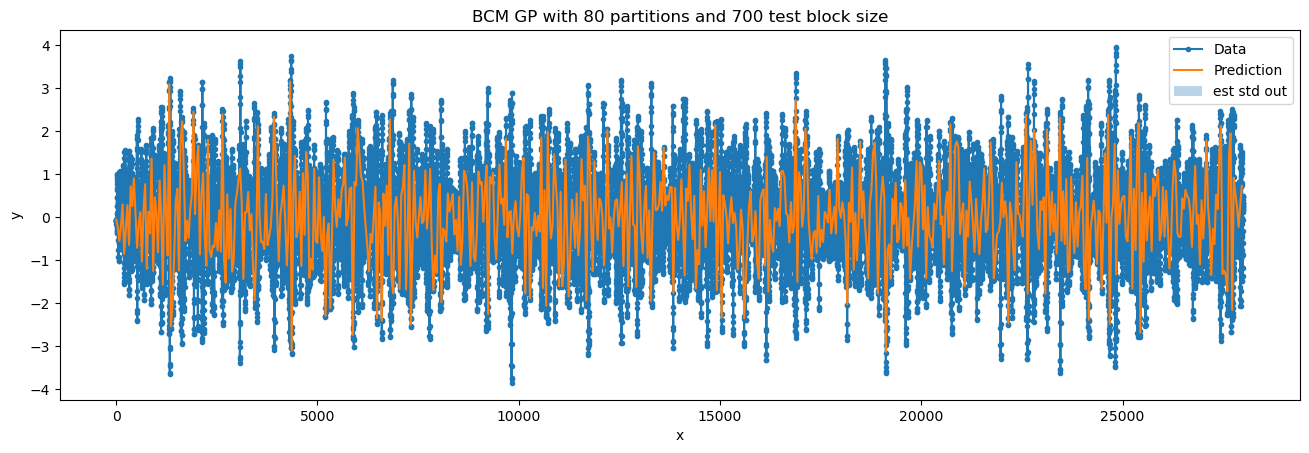

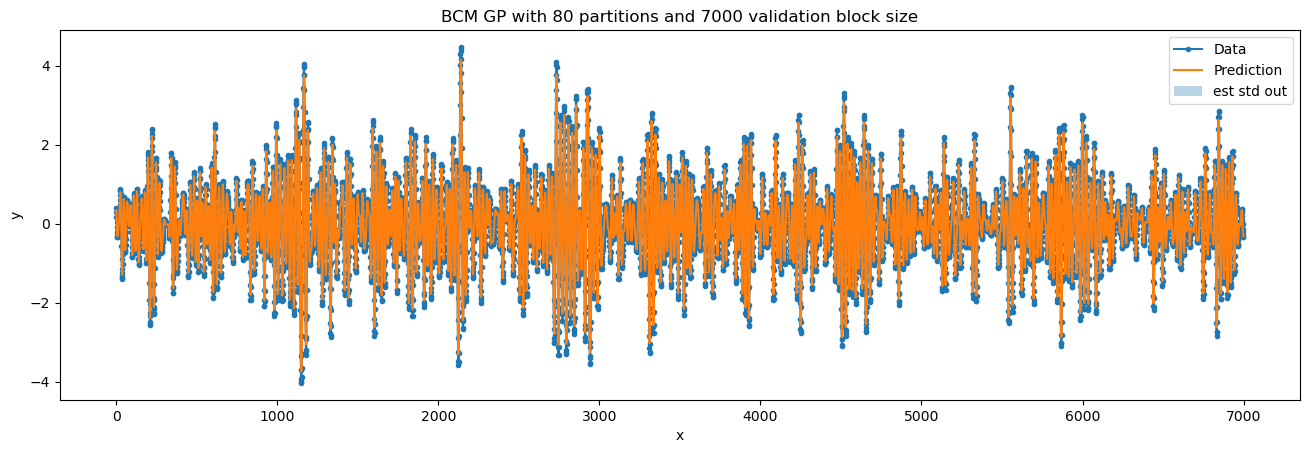

test RMSE:  0.0073639797597896675 
 validation RMSE:  0.03778853825039144


In [105]:

for p in range(p_bcm): print(reg_bcm[p].kernel_)

name = 'BCM GP with ' + str(p_bcm) + " partitions and " + str(int(N/N_div)) + " test block size"
demonstrate(range_tra,y_tra,f_bcm_test,var_bcm_test,testpoints_ind_bcm,name)

name = 'BCM GP with ' + str(p_bcm) + " partitions and " + str(int(V/V_div)) + " validation block size"
demonstrate(range_val,y_val,f_bcm_vali,var_bcm_vali,valipoints_ind_bcm,name)

print("test RMSE: ", test_rmse, "\n","validation RMSE: ", vali_rmse )

In [106]:
#test RMSE:  0.007363979744984681 
#validation RMSE:  0.03778853821144124

print("Log-marginal-likelihood:", reg_bcm[0].log_marginal_likelihood_value_)
print("Log-marginal-likelihood:", reg_bcm[0].kernel_)

Log-marginal-likelihood: 778.7106290967015
Log-marginal-likelihood: WhiteKernel(noise_level=0.001) + RBF(length_scale=7.01) + 0.00316**2


# Predictions task

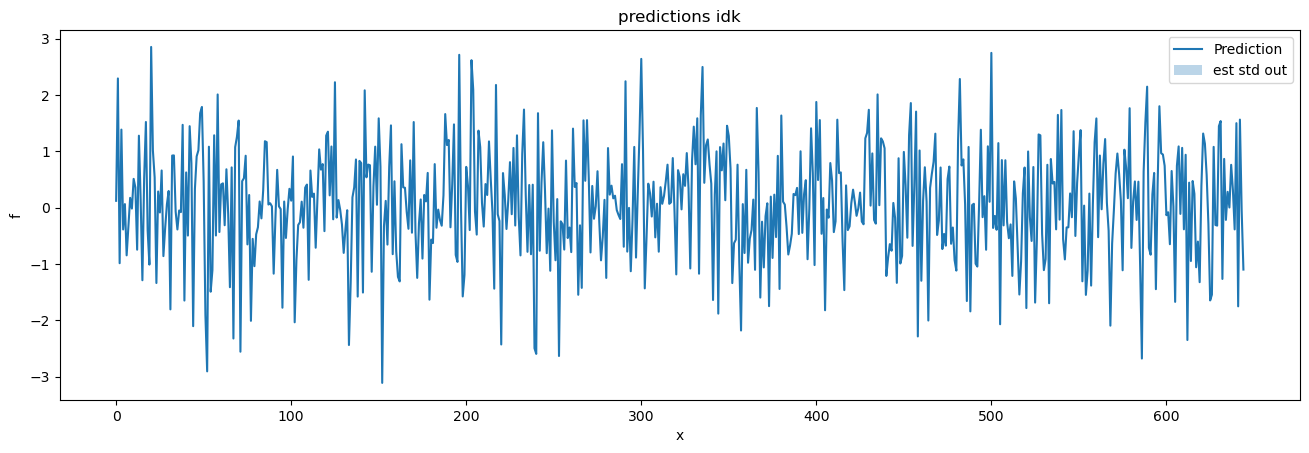

In [107]:

data = np.load('/home/sodium-nitrate/aur/gym-unbalanced-disk/disc-benchmark-files/hidden-test-prediction-submission-file.npz')
upast_test = data['upast'] #N by u[k-15],u[k-14],...,u[k-1]
thpast_test = data['thpast'] #N by y[k-15],y[k-14],...,y[k-1]
Xtest = np.concatenate([upast_test[:,15-order:15], thpast_test[:,15-order:15]],axis=1)

#Ypredict, Varpredict = reg_bcm[0].predict(Xtest,return_std=True)
Ypredict, Varpredict = BCM_predict(Xtest,reg_bcm,kernel,width_bcm,N)

np.savez('NITIN-hidden-test-prediction-example-submission-file.npz', upast=upast_test, thpast=thpast_test, thnow=Ypredict)

quick_plot(range(len(Xtest)),Ypredict,Varpredict,'predictions idk')
